# Tutorial 4: Two-Sample T-Tests

In this tutorial, you will learn how to compare the means of two independent samples using a **two-sample t-test**. This builds on Tutorial 3, where we calculated individual confidence intervals for each method. Now we ask: **Is there a statistically significant difference between the two methods?**

**What you'll practice (learning objectives):**

1. Check assumptions for two-sample t-tests (normality, equal variance)
2. Formulate null and alternative hypotheses
3. Calculate the pooled standard deviation and test statistic
4. Interpret results using both critical value and p-value methods
5. Compute a 95% confidence interval for the difference in means
6. Verify results using Python libraries

## Prepare Environment and Notebook

You may need to run this in a new cell first:

`%pip install statsmodels`

1. Let it finish installing
2. Restart the kernel (Kernel → Restart Kernel)
3. Delete the pip install cell before re-running your import cell

In [ ]:
%reset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

# Step 1: Load and Explore the Data

## Context: Comparing Two HbA1c Testing Methods

A clinic is comparing two HbA1c testing methods (e.g., a point-of-care device vs a central lab assay). We collect HbA1c (%) results from a sample of patients using Method A and Method B.

**Research Question: Is there a difference in mean HbA1c (%) between Method A and Method B?**

| Feature | Method A | Method B |
|---------|----------|----------|
| Measurement type | Point-of-care HbA1c device | Central laboratory assay |
| Sample handling | Finger-stick capillary blood | Venous blood draw |
| Turnaround time | Immediate (minutes) | Delayed (hours-days) |
| Typical use | Screening, rapid clinical decisions | Diagnostic confirmation |
| Potential variability | Higher (device noise, user technique) | Lower (controlled lab conditions) |

In [3]:
# Create pandas Series for each method's HbA1c measurements
A = pd.Series([6.34, 6.16, 6.32, 6.21, 6.36, 6.43, 6.02, 6.21, 6.47, 6.21, 6.49, 6.21, 6.16, 6.19, 6.29, 6.33, 6.51], name="MethodA")
B = pd.Series([6.38, 6.54, 6.49, 6.47, 6.46, 6.46, 6.52, 6.35, 6.33, 6.35, 6.31, 6.37, 6.13, 6.45], name="MethodB")

# Combine into a single DataFrame for easier analysis
df = pd.concat([A, B], axis="columns")
df

,MethodA,MethodB
0,6.34,6.38
1,6.16,6.54
2,6.32,6.49
3,6.21,6.47
4,6.36,6.46
5,6.43,6.46
6,6.02,6.52
7,6.21,6.35
8,6.47,6.33
9,6.21,6.35


Notice that Method A has 17 observations and Method B has 14 observations (NaN values appear where Method B has no data). This is common in real-world studies where sample sizes may differ.

## Step 1.2: Visualize the Data

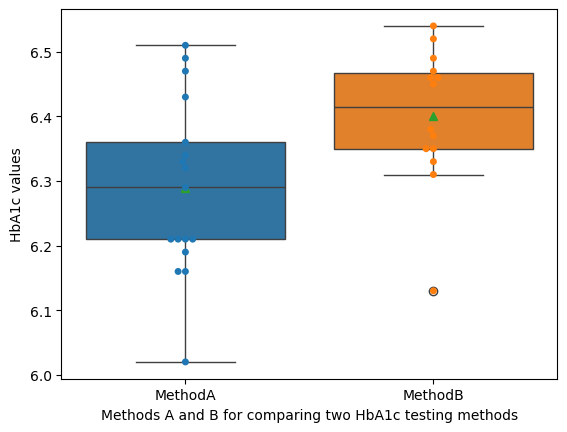

In [4]:
# Create boxplot with swarmplot overlay to show distribution and individual data points
sns.boxplot(data=df, showmeans=True)  # showmeans=True adds green triangle for mean
sns.swarmplot(data=df)  # Adds individual data points
plt.xlabel("Methods A and B for comparing two HbA1c testing methods")
plt.ylabel("HbA1c values")
plt.show()

**How to read this plot:**
- **Box:** Shows the interquartile range (IQR) — the middle 50% of the data (25th to 75th percentile)
- **Horizontal line in box:** Median (50th percentile)
- **Green triangle:** Mean (average)
- **Whiskers:** Extend to 1.5 × IQR from the box edges
- **Individual dots:** Each actual data point (from swarmplot)
- **Dots outside whiskers:** Potential outliers (see the one low point in Method B around 6.15)

**Initial observations:** Method B appears to have a slightly higher center (mean and median) than Method A. The spread looks similar for both methods.

## Step 1.3: Summary Statistics

In [5]:
df.describe()

,MethodA,MethodB
count,17.000000,14.000000
mean,6.288824,6.400714
std,0.135226,0.107020
min,6.020000,6.130000
25%,6.210000,6.350000
50%,6.290000,6.415000
75%,6.360000,6.467500
max,6.510000,6.540000


# Step 2: Check Assumptions for the Two-Sample T-Test

Before running a two-sample t-test, we must verify these assumptions:

1. **Independence:** Samples are independent from each other (not linked or paired)
2. **Normality:** Data in each group is approximately normally distributed
3. **Equal Variance (Homoscedasticity):** The variances of the two populations are equal

We assume independence based on the study design. Now we'll test normality and equal variance.

## Step 2.1: Check Normality (Jarque-Bera Test)

The **Jarque-Bera test** checks whether sample data has the skewness and kurtosis matching a normal distribution.

- **Null hypothesis (H₀):** The data IS normally distributed
- **Alternative hypothesis (H₁):** The data is NOT normally distributed
- **Decision:** If p-value > 0.05, we fail to reject H₀ and conclude the data is approximately normal

In [6]:
# Test normality for Method A
stats.jarque_bera(A)

SignificanceResult(statistic=np.float64(0.355779088301175), pvalue=np.float64(0.8370348737808077))

**Method A result:** p-value = 0.837 > 0.05 → Fail to reject H₀ → Data is approximately normal

In [7]:
# Test normality for Method B
stats.jarque_bera(B)

SignificanceResult(statistic=np.float64(2.7753543869469692), pvalue=np.float64(0.24965453082962577))

**Method B result:** p-value = 0.250 > 0.05 → Fail to reject H₀ → Data is approximately normal 

Both samples pass the normality test.

## Step 2.2: Check Equality of Variance (Levene's Test)

Now that we've confirmed normality, we need to check our second assumption: equal variances.

**Levene's test** checks whether two or more groups have equal variances (homoscedasticity). This assumption matters because when variances are equal, we can combine (pool) variance estimates from both samples, which increases the precision of our test.

- **Null hypothesis (H₀):** The variances ARE equal
- **Alternative hypothesis (H₁):** The variances are NOT equal
- **Decision:** If p-value > 0.05, we fail to reject H₀ and conclude variances are equal

In [8]:
# Levene's test with center='median' (more robust to non-normality)
stats.levene(A, B, center='median')

LeveneResult(statistic=np.float64(1.1719598300964171), pvalue=np.float64(0.28791858578858187))

**Result:** p-value = 0.288 > 0.05 → Fail to reject H₀ → **Variances are equal** 

**Conclusion:** Since both the normality assumption (Step 2.1) and equal variance assumption are satisfied, we can proceed with the standard two-sample t-test using the **pooled variance** approach.

## Step 2.3: Visual Check with QQ Plots

QQ plots provide a visual way to assess normality. If data is normally distributed, points should fall approximately along the 45-degree reference line.

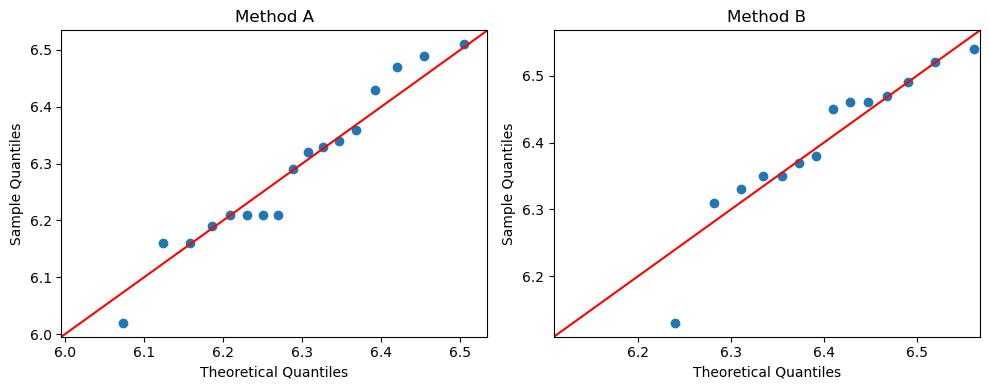

In [9]:
# Create side-by-side QQ plots for both methods
fig2, ax2 = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# QQ plot for Method A (left)
sm.qqplot(A, line='45', loc=np.mean(A), scale=np.std(A, ddof=1), ax=ax2[0])
ax2[0].set_title("Method A")

# QQ plot for Method B (right)
sm.qqplot(B, line='45', loc=np.mean(B), scale=np.std(B, ddof=1), ax=ax2[1])
ax2[1].set_title("Method B")

plt.tight_layout()
plt.show()

**How to read QQ plots:**
- **X-axis:** Theoretical quantiles (where points SHOULD be if data is normal)
- **Y-axis:** Sample quantiles (where points ACTUALLY are in your data)
- **Red line:** The "perfect normal" reference line
- **Good sign:** Points fall close to the red line
- **Bad sign:** Systematic deviations (S-curves indicate skewness, endpoints far from line indicate heavy tails)

**Our results:** Both plots show points following the line reasonably well. Minor deviations at the tails are acceptable, especially with small sample sizes. The normality assumption is satisfied.

# Step 3: Formulate Hypotheses and Calculate Test Statistic

## Step 3.1: State the Hypotheses

Now that we've verified our assumptions, we can proceed with the two-sample t-test.

**Why do we state hypotheses?** Hypothesis testing provides a formal framework for making decisions about population parameters based on sample data. We set up competing claims and use data to determine which is more likely.

**This is a two-sided test** because we're testing if there's ANY difference (not specifically if one is greater than the other).

- **Null hypothesis (H₀):** μ_A = μ_B (the population means are equal — no difference)
- **Alternative hypothesis (H₁):** μ_A ≠ μ_B (the population means are different)
- **Significance level:** α = 0.05

## Step 3.2: Calculate Sample Statistics

Before calculating the test statistic, we need several values from our samples.

In [10]:
# Sample sizes
nA = len(A)  # Number of observations in Method A
nB = len(B)  # Number of observations in Method B

# Sample standard deviations (ddof=1 for sample std dev)
stdA = np.std(A, ddof=1)
stdB = np.std(B, ddof=1)

# Print all statistics
print("Sample sizes: nA =", nA, ", nB =", nB)
print("Sample means: x̄_A =", round(np.mean(A), 4), ", x̄_B =", round(np.mean(B), 4))
print("Sample std devs: s_A =", round(stdA, 4), ", s_B =", round(stdB, 4))
print("Sample variances: s²_A =", round(stdA**2, 4), ", s²_B =", round(stdB**2, 4))
print("Degrees of freedom: df =", nA + nB - 2)

Sample sizes: nA = 17 , nB = 14
Sample means: x̄_A = 6.2888 , x̄_B = 6.4007
Sample std devs: s_A = 0.1352 , s_B = 0.107
Sample variances: s²_A = 0.0183 , s²_B = 0.0115
Degrees of freedom: df = 29


## Step 3.3: Calculate the Pooled Standard Deviation

In Step 2.2, Levene's test confirmed that the variances of our two samples are equal (p = 0.288 > 0.05). Because this assumption is satisfied, we can **pool** the two sample variances into a single, combined estimate. Pooling uses information from both samples, which gives us a more precise estimate of the common variance and increases the statistical power of our test.

**Pooled Standard Deviation Formula:**

$$s_p = \sqrt{\frac{(n_A - 1) \cdot s_A^2 + (n_B - 1) \cdot s_B^2}{n_A + n_B - 2}}$$

This formula computes a weighted average of the two sample variances, where each variance is weighted by its degrees of freedom (n - 1).

### TASK 1: Calculate the Pooled Standard Deviation

Using the formula above and the variables `nA`, `nB`, `stdA`, and `stdB`, calculate `s_pooled`.

**Hint:** Use `np.sqrt()` for the square root. The numerator is `(nA-1)*stdA**2 + (nB-1)*stdB**2`

In [11]:
# --- YOUR CODE HERE ---
numerator = (nA - 1) * (stdA**2) + (nB - 1) * (stdB**2)
denominator = nA + nB - 2
s_pooled = np.sqrt(numerator / denominator)
# --- END YOUR CODE ---

print("Pooled standard deviation: s_p =", round(s_pooled, 4))

Pooled standard deviation: s_p = 0.1234


## Step 3.4: Calculate the Standard Error of the Difference

The **standard error of the difference** quantifies the uncertainty in our estimate of the difference between the two population means. It accounts for both the variability within each sample and the sample sizes.

$$SE_{diff} = s_p \cdot \sqrt{\frac{1}{n_A} + \frac{1}{n_B}}$$

In [12]:
# Calculate standard error of the difference
StandErrorDiff = s_pooled * np.sqrt(1/nA + 1/nB)
print("Standard error of the difference: SE =", round(StandErrorDiff, 4))

Standard error of the difference: SE = 0.0445


A smaller SE indicates more precision in estimating the true difference. With larger sample sizes or less variability in the data, the SE decreases.

## Step 3.5: Calculate the Difference in Means

In [13]:
# Calculate the observed difference in sample means
diffmeans = np.mean(A) - np.mean(B)
print("Difference in means (x̄_A - x̄_B) =", round(diffmeans, 4))

Difference in means (x̄_A - x̄_B) = -0.1119


The negative value indicates that Method A has a lower mean than Method B (by about 0.11 HbA1c units).

## Step 3.6: Calculate the t-statistic

The **t-statistic** measures how far the observed difference in means is from zero (the value expected under the null hypothesis), expressed in units of standard error.

$$t = \frac{\bar{X}_A - \bar{X}_B}{SE_{diff}} = \frac{\bar{X}_A - \bar{X}_B}{s_p \cdot \sqrt{\frac{1}{n_A} + \frac{1}{n_B}}}$$

A larger | t | indicates the observed difference is further from what we'd expect if there were no true difference, providing stronger evidence against the null hypothesis.

### TASK 2: Calculate the t-statistic

Using `diffmeans` and `StandErrorDiff`, calculate the t-statistic.

In [14]:
# --- YOUR CODE HERE ---
t_stat = diffmeans / StandErrorDiff
# --- END YOUR CODE ---

print("t-statistic =", round(t_stat, 4))

t-statistic = -2.5128


The t-statistic of approximately -2.51 tells us the observed difference is about 2.51 standard errors below zero.

# Step 4: Make a Decision (Critical Value and P-Value Methods)

Now that we have our t-statistic, we need to determine whether it provides enough evidence to reject the null hypothesis. There are two equivalent approaches:

1. **Critical Value Method:** Compare | t_stat | to a threshold value from the t-distribution
2. **P-Value Method:** Calculate the probability of observing a result this extreme if H₀ were true

Both methods will lead to the same conclusion.

## Method 1: Critical Value Method

For a two-tailed test at α = 0.05, we find the critical t-value that cuts off 2.5% in each tail.

In [15]:
# Find critical t-value for two-tailed test at α = 0.05 with df = 29
# We use 0.975 because we want the value with 97.5% to the left (leaving 2.5% in the upper tail)
Critical_t = stats.t.ppf(0.975, df=29)
print("Critical t-value (±): ", round(Critical_t, 4))
print("Our t-statistic:      ", round(t_stat, 4))

Critical t-value (±):  2.0452
Our t-statistic:       -2.5128


**Decision Rule:** If | t_stat | > Critical_t, reject H₀.

Since | −2.51 | = 2.51 > 2.05, our test statistic falls in the **rejection region**.

## Method 2: P-Value Method

The p-value is the probability of observing a test statistic as extreme as ours (or more extreme) if the null hypothesis were true.

In [16]:
# For a two-tailed test, multiply the one-tailed p-value by 2
# stats.t.cdf gives the area to the LEFT of the t-value
p_value = 2 * stats.t.cdf(t_stat, df=29)  # t_stat is negative, so cdf gives left tail
print("Two-tailed p-value =", round(p_value, 4))

Two-tailed p-value = 0.0178


**Decision Rule:** If p-value < α (0.05), reject H₀.

Since p-value = 0.0178 < 0.05, we **reject the null hypothesis**.

### **QUESTION 1:**

a) Based on the critical value method, do we reject or fail to reject the null hypothesis? Explain why.

b) Based on the p-value method, do we reject or fail to reject the null hypothesis? Explain why.

c) What do we conclude about the difference between Method A and Method B?

**YOUR ANSWER:**

a) Based on the critical value method, we reject the null hypothesis. The reason why we reject the null hypothesis based on the critical value method is that when comparing the absolute value of the calculated t-statistic to the critical value, this value is greater than the critical value by .46 as t_stat = 2.51 and critical_t = 2.05. This indicates that the observed difference is too large to be attributed to random sampling error alone.

b) Based on the p-value method, we will also reject the null hypothesis. The reason why we reject the null hypothesis based on the p-value method is that when p-value is less than the alpha value of 0.05. Our calculated p-value is 0.0178, which is significantly lower than 0.05.

c) What we can conclude about the difference between Method A and Method B is that there is statistically significant difference between the population means of Method A and Method B.

# Step 5: 95% Confidence Interval for the Difference in Means

While hypothesis testing tells us whether a difference exists, a confidence interval tells us the likely range of that difference.

**Formula:**
$$(\bar{x}_A - \bar{x}_B) \pm t_{crit} \cdot SE_{diff}$$

**Key interpretation:** If the 95% CI does NOT contain 0, then zero is not a plausible value for the true difference, which means the difference is statistically significant at α = 0.05. This aligns with our hypothesis test result.

### TASK 3: Calculate the 95% Confidence Interval

Using `diffmeans`, `Critical_t`, and `StandErrorDiff`, calculate the lower and upper bounds.

**Hint:** Lower bound = diffmeans - Critical_t * StandErrorDiff

In [17]:
# --- YOUR CODE HERE ---
margin_of_error = Critical_t * StandErrorDiff
LB = diffmeans - margin_of_error
UB = diffmeans + margin_of_error
# --- END YOUR CODE ---

print("95% CI for (μ_A - μ_B): [", round(LB, 4), ",", round(UB, 4), "]")

95% CI for (μ_A - μ_B): [ -0.203 , -0.0208 ]


### **QUESTION 2:**

Interpret the 95% confidence interval. Does it contain 0? What does this tell us about the statistical significance of the difference?

**YOUR ANSWER:**

The 95% confidence interval does not contain zero. Both the lower bound -0.203 and the upper bound -0.0208 are negative numbers. We conclude that the difference between Method A and Method B is statistically significant at the alpha 0.05 level. If zero were in the interval, it would imply that "no difference" is a plausible reality, however, since it is excluded, we have enough evidence to claim a real difference exists.

# Step 6: Verify Results Using Python

Python has built-in functions that perform these calculations automatically. Verifying that our manual results match the function outputs confirms we've done the calculations correctly.

## 6.1 Two-Sample t-test (scipy)

In [18]:
# scipy's ttest_ind performs an independent two-sample t-test
# equal_var=True uses pooled variance (Student's t-test)
stats.ttest_ind(A, B, equal_var=True)

TtestResult(statistic=np.float64(-2.512757467716067), pvalue=np.float64(0.0177924301536104), df=np.float64(29.0))

**Compare:** t-statistic and p-value should match our manual calculations.

## 6.2 Two-Sample t-test (statsmodels)

In [19]:
# statsmodels returns: (t-statistic, p-value, degrees of freedom)
sm.stats.ttest_ind(A, B, usevar='pooled')

(np.float64(-2.512757467716067),
 np.float64(0.0177924301536104),
 np.float64(29.0))

## 6.3 Confidence Interval Verification

In [20]:
# Verify our CI calculation
stats.t.interval(confidence=0.95, df=29, loc=diffmeans, scale=StandErrorDiff)

(np.float64(-0.20296293275039948), np.float64(-0.020818579854642277))

## 6.4 Non-Parametric Alternative: Mann-Whitney U Test

If normality assumptions were violated, we would use the **Mann-Whitney U test** instead. This non-parametric test compares medians rather than means.

In [21]:
stats.mannwhitneyu(A, B, use_continuity=False, alternative='two-sided')

MannwhitneyuResult(statistic=np.float64(61.5), pvalue=np.float64(0.02224798302276019))

The Mann-Whitney test also shows p = 0.022 < 0.05, confirming a significant difference even with a non-parametric approach.

---
### **REFLECTION:**

Based on the results of this analysis, what would you recommend to a clinic deciding between Method A and Method B for HbA1c testing? Consider both the statistical significance and the practical/clinical significance of the ~0.11% difference.

**YOUR ANSWER:**

Both the Student's t-test 0.0178 and the non-parametric Mann-Whitney U test p = 0.0222 confirm that the difference between the two methods is statistically significant. In HbA1c testing, a difference of 0.11% is often considered small, as clinical decisions like for example changing to a specific medication,  0.5% or more would make a difference. However, the clinic should consider there is a statistically significant bias, these two methods are not interchangeable and can cause possible bias in testing. Therefore, they should stick to one method, for example Method A, for their baseline.

# Submission Instructions

**Due Date:** Friday, February 7, 2026

**How to Submit:**
1. Make sure all code cells have been run and show outputs
2. Make sure all TASK cells are completed with your code
3. Make sure all QUESTION cells are filled in with your answers
4. Save your notebook as: `Tutorial4_YourName.ipynb`
5. Export as PDF (File → Save and Export Notebook As → PDF)
6. Submit both the .ipynb and PDF to the Tutorial 4 dropbox on Avenue to Learn

**Need Help?**
- Jala and Imran will be available during office hours **Wednesday** and **Thursday**
- Check Avenue to Learn for office hours times and locations
- You can also post questions on the course discussion board